# Receiver Operating Characteristic (ROC) Curves

In this notebook, we will explain how to generate a Receiver Operating Characteristic (ROC) curve using this module. It is recommended to read the first tutorial, titled **"Setting Parameters,"** before going through this one.

#### Plan of this notebook

1. Brief introduction to ROC curves
2. Computing the ROC curve

## 1) Brief introduction to the ROC curve

The ROC curve is a graphical representation of the performance of a binary classifier as its discrimination threshold is varied. It is obtained by plotting the true positive probability against the false positive probability. Why is this useful?

ROC curves are an essential tool for evaluating the performance of a binary classifier. In the context of LiDAR, the two possible outcomes are whether a target is detected or not. By varying the detection threshold, the ROC curve shows the probability of detecting a target while avoiding false detections caused by noise. Analyzing ROC curves therefore provides a more complete picture of the system's performance than the SNR alone.

For instance, consider System A, which detects 2 photons per second when the target is present and 1 photon per second when the target is absent. Compare this with System B, which detects 100 photons per second when the target is present and 50 photons per second when the target is absent. In both cases, the SNR is one. However, System B provides a much larger number of detection events for the same acquisition time, making it easier to statistically distinguish the target signal from the background noise.

This example illustrates why the SNR alone does not fully characterize the performance of a LiDAR system. The absolute signal and noise rates also play an important role in determining how reliably a target can be detected.

## 2) Computing the ROC Curve

The following parameters are required to compute the ROC curve:

* `signal_rate`: Rate at which photons are detected in the bins associated with the target's time of flight.
* `noise_rate`: Rate at which photons are detected in the bins not associated with the target's time of flight, or when the target is absent.
* `trigger_rate`: Effective triggering rate of the system. It is the rate at which the single-photon detector is triggered.
* `threshold_limit`: Maximum detection threshold that will be tested when generating the ROC curve. It should be large enough that the probability of exceeding it is statistically negligible.
* `range_interval`: Maximum distance between the LiDAR and the target that can be detected. The larger this interval, the more time bins are required, which increases the probability of a false detection.
* `timing_window`: Time interval during which the LiDAR system is able to detect photons.
* `acquisition_time`: Total time, in seconds, during which the LiDAR system acquires data.
* `precision`: Number of points considered in the threshold array between two consecutive integer thresholds. The threshold step is given by $1/\text{precision}$.

### Example: Compute the three sources

Let's begin by importing the module and setting the parameters. We will then compute the ROC curves for the three sources.

In [1]:
from Sources import SetupParameters, SinglePhoton, EntangledPhotonSPDC, PulsedLaser
from Analysis import RocAnalysis
import matplotlib.pyplot as plt

param = SetupParameters(
	fock_space_dim=5,
	output_power=2e6,
	multi_photon_probability=None,
	no_vacuum_probability=None,
	number_nv_pulse=None,
	sp_collection=0.8,
	sp_p1=0.99,
	sp_p2=1e-3,
	spdc_eps_heralding=0.4,
	spdc_eps_collection=0.8,
	atmosphere=1,
	target_distance=1.5,
	receiver_diameter=0.05,
	target_albedo=0.2,
	optics_transmitter=0.8,
	optics_receiver=0.5,
	detection_efficiency=0.5,
	background=2e5,
	detector_dark=100,
	timing_window=0.5e-9,
)

sps = SinglePhoton(param, warning_off=True)
multi_photon_probability = sps.multi_photon_probability
param["multi_photon_probability"] = multi_photon_probability

laser = PulsedLaser(param)
eps = EntangledPhotonSPDC(param)

Now, we can compute the parameters needed for each sources in order to compute the ROC Curves.

In [3]:
# Laser

signal_rate_laser = laser.signal_rate()
noise_rate_laser = laser.noise_rate()
trigger_rate_laser = laser.trigger_rate

# Single Photon Source

signal_rate_sp = sps.signal_rate()
noise_rate_sp = sps.noise_rate()
trigger_rate_sp = sps.trigger_rate

# Entangled Photon Source

signal_rate_eps = eps.signal_rate()
noise_rate_eps = eps.noise_rate()
trigger_rate_eps = eps.trigger_rate

The ROC Curves can now be computed for each source using the `RocAnalysis` class.

In [4]:
acquisition_time = 1
precision = 20
range_interval = 50

true_positive_laser, false_positive_laser = RocAnalysis(
	signal_rate=signal_rate_laser,
	noise_rate=noise_rate_laser,
	trigger_rate=trigger_rate_laser,
	threshold_limit=trigger_rate_laser/100,
	range_interval=range_interval,
	timing_window=param["timing_window"],
	acquisition_time=acquisition_time,
	precision=precision,
).compute_p_d_p_fa()

true_positive_sp, false_positive_sp = RocAnalysis(
	signal_rate=signal_rate_sp,
	noise_rate=noise_rate_sp,
	trigger_rate=trigger_rate_sp,
	threshold_limit=trigger_rate_sp/100,
	range_interval=range_interval,
	timing_window=param["timing_window"],
	acquisition_time=acquisition_time,
	precision=precision,
).compute_p_d_p_fa()

true_positive_eps, false_positive_eps = RocAnalysis(
	signal_rate=signal_rate_eps,
	noise_rate=noise_rate_eps,
	trigger_rate=trigger_rate_eps,
	threshold_limit=trigger_rate_eps/100,
	range_interval=range_interval,
	timing_window=param["timing_window"],
	acquisition_time=acquisition_time,
	precision=precision,
).compute_p_d_p_fa()

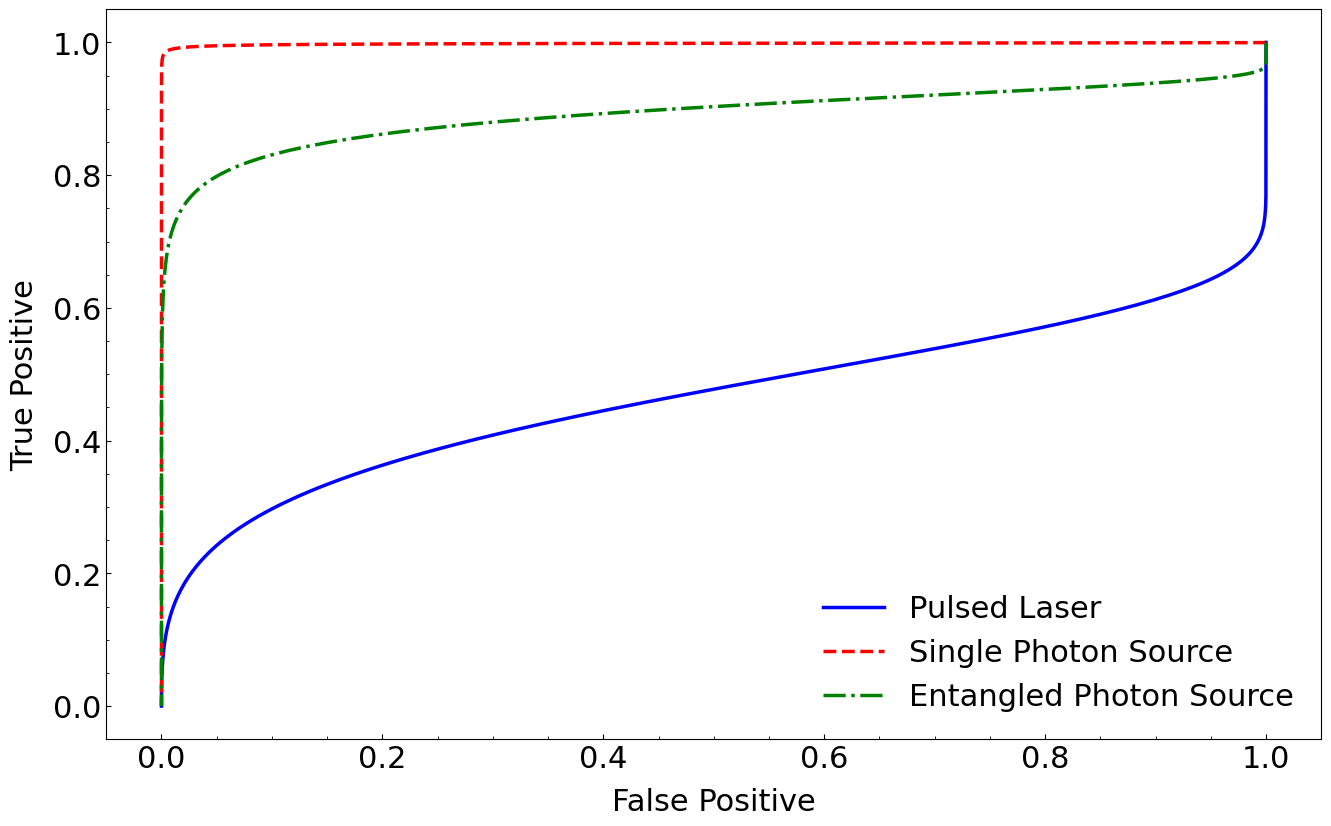

In [5]:
plt.style.use("https://raw.githubusercontent.com/dccote/Enseignement/master/SRC/dccote-errorbars.mplstyle")

fig = plt.figure(figsize=(16.2, 10))

plt.plot(false_positive_laser, true_positive_laser, "-", label="Pulsed Laser", color="blue", linewidth=2.5)
plt.plot(false_positive_sp, true_positive_sp, "--", label="Single Photon Source", color="red", linewidth=2.5)
plt.plot(false_positive_eps, true_positive_eps, "-.", label="Entangled Photon Source", color="green", linewidth=2.5)
plt.xlabel("False Positive", fontsize=22)
plt.ylabel("True Positive", fontsize=22)
plt.legend(frameon=False, fontsize=22)
plt.tick_params(axis='both', which='major', labelsize=22)
plt.tick_params(axis='both', which='minor', labelsize=22)
plt.show()